# Tox21 Baseline Comparison (7 Modelle)

Dieses Notebook vergleicht auf **demselben Split** sieben Baselines fuer **Tox21 Multi-Label Classification (12 Assays)**:
1. RF auf Graph-Features (task-wise One-vs-Rest)
2. RF auf RDKit-Deskriptoren (task-wise One-vs-Rest)
3. ChebNet von Scratch (task-wise, je Assay ein Modell)
4. ChebNet mit Foundation-Checkpoint (task-wise 2-stage FT)
5. Standard-SEG (echtes Multi-Label mit NaN-masked BCE)
6. SEG: Foundation-ChebNet direkt kopiert -> end-to-end Fine-Tuning
7. SEG: Foundation -> Cheb Tox21-Mix FT -> SEG -> end-to-end Fine-Tuning

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

import deepchem as dc
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.cheb_predictor import ChebPredictor, ChebPredictorConfig
from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache
from utils.molecular_graph import smiles_to_graph

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

print(f'Workspace root: {workspace_root}')
print(f'Device: {device}')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace root: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
def set_all_seeds(s):
    s = int(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

def to_binary01(y):
    y = np.asarray(y, dtype=np.float32)
    # Tox21 should be 0/1, but keep robust conversion if {-1,1} appears.
    uniq = np.unique(y[np.isfinite(y)])
    runiq = set(np.round(uniq).tolist())
    if runiq.issubset({0.0, 1.0}):
        return y.astype(np.float32)
    if runiq.issubset({-1.0, 1.0}):
        return (y > 0).astype(np.float32)
    raise ValueError(f'Unsupported label values: {uniq}')

def best_threshold_binary(y_true, y_pred_proba):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred_proba = np.asarray(y_pred_proba, dtype=np.float32).reshape(-1)
    m = np.isfinite(y_true) & np.isfinite(y_pred_proba)
    y_true = y_true[m]
    y_pred_proba = np.clip(y_pred_proba[m], 0.0, 1.0)
    if y_true.size == 0:
        return 0.5

    best_thr = 0.5
    best_f1 = -1.0
    best_acc = -1.0
    for thr in np.linspace(0.05, 0.95, 181):
        y_hat = (y_pred_proba >= thr).astype(np.float32)
        tp = float(np.sum((y_hat == 1) & (y_true == 1)))
        tn = float(np.sum((y_hat == 0) & (y_true == 0)))
        fp = float(np.sum((y_hat == 1) & (y_true == 0)))
        fn = float(np.sum((y_hat == 0) & (y_true == 1)))
        acc = float((tp + tn) / max(tp + tn + fp + fn, 1.0))
        precision = float(tp / max(tp + fp, 1.0))
        recall = float(tp / max(tp + fn, 1.0))
        f1 = float(2.0 * precision * recall / max(precision + recall, 1e-12))
        if (f1 > best_f1) or (np.isclose(f1, best_f1) and acc > best_acc):
            best_f1 = f1
            best_acc = acc
            best_thr = float(thr)
    return best_thr

def multilabel_metrics(y_true, y_pred, observed_mask, thresholds=None):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    observed_mask = np.asarray(observed_mask, dtype=bool)

    n_tasks = y_true.shape[1]
    if thresholds is None:
        thresholds = np.full(n_tasks, 0.5, dtype=np.float32)
    else:
        thresholds = np.asarray(thresholds, dtype=np.float32)

    aucs, accs, f1s = [], [], []
    for t in range(n_tasks):
        mask_t = observed_mask[:, t] & np.isfinite(y_pred[:, t])
        if mask_t.sum() == 0:
            aucs.append(np.nan); accs.append(np.nan); f1s.append(np.nan)
            continue

        yt = y_true[mask_t, t]
        yp = np.clip(y_pred[mask_t, t], 0.0, 1.0)
        if len(np.unique(yt)) >= 2:
            try:
                aucs.append(float(roc_auc_score(yt, yp)))
            except Exception:
                aucs.append(np.nan)
        else:
            aucs.append(np.nan)

        yh = (yp >= thresholds[t]).astype(np.float32)
        accs.append(float(accuracy_score(yt, yh)))
        f1s.append(float(f1_score(yt, yh, zero_division=0)))

    return {
        'macro_roc_auc': float(np.nanmean(aucs)) if np.isfinite(np.nanmean(aucs)) else np.nan,
        'macro_accuracy': float(np.nanmean(accs)) if np.isfinite(np.nanmean(accs)) else np.nan,
        'macro_f1': float(np.nanmean(f1s)) if np.isfinite(np.nanmean(f1s)) else np.nan,
        'n_valid_auc_tasks': int(np.sum(np.isfinite(np.asarray(aucs, dtype=np.float32)))),
        'per_task_auc': aucs,
        'per_task_acc': accs,
        'per_task_f1': f1s,
    }

In [3]:
# Tox21 from DeepChem with weight masks for missing labels.
# Use scaffold split for consistency with the other baseline notebooks.
tasks, datasets, _ = dc.molnet.load_tox21(featurizer='ECFP', splitter='random')
train_dc, valid_dc, test_dc = datasets

task_names = list(tasks)
n_tasks = len(task_names)

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

train_y_raw = np.asarray(train_dc.y, dtype=np.float32)
valid_y_raw = np.asarray(valid_dc.y, dtype=np.float32)
test_y_raw = np.asarray(test_dc.y, dtype=np.float32)

train_w = np.asarray(train_dc.w, dtype=np.float32) > 0.0
valid_w = np.asarray(valid_dc.w, dtype=np.float32) > 0.0
test_w = np.asarray(test_dc.w, dtype=np.float32) > 0.0

train_y = to_binary01(train_y_raw)
valid_y = to_binary01(valid_y_raw)
test_y = to_binary01(test_y_raw)

# SEG expects NaN for missing labels in multi-label mode.
train_y_nan = train_y.copy()
valid_y_nan = valid_y.copy()
test_y_nan = test_y.copy()
train_y_nan[~train_w] = np.nan
valid_y_nan[~valid_w] = np.nan
test_y_nan[~test_w] = np.nan

print(f'Tox21 tasks: {n_tasks}')
print(f'Split sizes -> train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}')
print(f'Observed labels -> train={int(train_w.sum())}, val={int(valid_w.sum())}, test={int(test_w.sum())}')

Failed to featurize datapoint 1322, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
Failed to featurize datapoint 2290, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
Failed to featurize datapoint 2297, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool brea

Tox21 tasks: 12
Split sizes -> train=6258, val=782, test=783
Observed labels -> train=62276, val=7705, test=7883


In [4]:
def _impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(train_X, axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)

def graph_feature_vector_from_smiles(smiles):
    g = smiles_to_graph(smiles, add_hydrogens=False)
    X = np.asarray(g.X, dtype=np.float32)
    ew = np.asarray(g.edge_weight, dtype=np.float32)

    x_sum = X.sum(axis=0)
    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0)

    n_nodes = float(g.n_nodes)
    n_edges_undir = float(g.edge_index.shape[1] // 2)
    ew_mean = float(ew.mean()) if ew.size else 0.0
    ew_std = float(ew.std()) if ew.size else 0.0
    ew_sum = float(ew.sum()) if ew.size else 0.0

    return np.concatenate([
        x_sum, x_mean, x_std,
        np.array([n_nodes, n_edges_undir, ew_mean, ew_std, ew_sum], dtype=np.float32),
    ])

def build_graph_feature_matrix(smiles_list):
    rows = []
    for smi in smiles_list:
        try:
            rows.append(graph_feature_vector_from_smiles(smi))
        except Exception:
            rows.append(np.full((89,), np.nan, dtype=np.float32))
    return np.vstack(rows).astype(np.float32)

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue
        all_descs = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_descs.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))
    return np.vstack(rows).astype(np.float32), desc_names

In [5]:
# Feature matrices for RF baselines.
g_train = build_graph_feature_matrix(train_smiles)
g_valid = build_graph_feature_matrix(valid_smiles)
g_test = build_graph_feature_matrix(test_smiles)
g_train, g_valid, g_test = _impute_with_train_median(g_train, g_valid, g_test)

d_train, desc_names = rdkit_descriptor_matrix(train_smiles)
d_valid, _ = rdkit_descriptor_matrix(valid_smiles)
d_test, _ = rdkit_descriptor_matrix(test_smiles)
d_train, d_valid, d_test = _impute_with_train_median(d_train, d_valid, d_test)

print('Graph feature dim:', g_train.shape[1])
print('RDKit descriptor dim:', d_train.shape[1])

C:\Users\robsc\AppData\Local\Temp\ipykernel_26888\3726926133.py:60: RuntimeWarning: overflow encountered in cast
  rows.append(np.asarray(row, dtype=np.float32))


Graph feature dim: 89
RDKit descriptor dim: 217


In [6]:
CHEB_CFG = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'sum',
}

# Per-task Cheb settings (single-output binary model per assay).
VANILLA_FIT_KWARGS = {
    'batch_size': 64,
    'num_epochs': 120,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'patience': 20,
}

CHEB_FIT_KWARGS = {
    'batch_size': 64,
    'frozen_epochs': 30,
    'unfreeze_epochs': 90,
    'head_lr': 5e-4,
    'encoder_lr': 5e-5,
    'weight_decay': 1e-1,
    'patience': 20,
}

# SEG multi-label setup; aligned with tox21 tuning defaults.
SEG_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'sum',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'text_proj_init': 'xavier',
    'text_proj_init_gain': 0.1,
    'freeze_text_proj': True,
    'dropout': 0.3,
    'fusion_dropout': 0.3,
    'head_dropout': 0.6,
    'weight_decay': 1e-1,
    'head_type': 'mlp',
    'head_hidden_dim': 64,
    'learning_rate': 3e-4,
    'batch_size': 64,
    'num_epochs': 100,
    'patience': 20,
    'scheduler': 'cosine',
    'scheduler_patience': 5,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': None,
}

SEG_CHEB_INIT_FIT_KWARGS = {**SEG_FIT_KWARGS, **{
    'hidden_channels': CHEB_CFG['hidden_channels'],
    'K': CHEB_CFG['K'],
    'num_layers': CHEB_CFG['num_layers'],
    'pool': CHEB_CFG['pool'],
    'learning_rate': 2e-4,
}}

def make_tox21_cheb_config():
    return ChebPredictorConfig(
        task='classification',
        hidden_channels=CHEB_CFG['hidden_channels'],
        K=CHEB_CFG['K'],
        num_layers=CHEB_CFG['num_layers'],
        pool=CHEB_CFG['pool'],
        dropout=0.3,
        lambda_max=2.0,
        add_hydrogens=False,
        head_hidden_dim=32,
        head_dropout=0.5,
    )

def make_seg_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='classification',
        num_tasks=n_tasks,
        hidden_channels=SEG_FIT_KWARGS['hidden_channels'],
        K=SEG_FIT_KWARGS['K'],
        num_layers=SEG_FIT_KWARGS['num_layers'],
        dropout=SEG_FIT_KWARGS['dropout'],
        pool=SEG_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_FIT_KWARGS['fusion'],
        fusion_dim=SEG_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_FIT_KWARGS['head_dropout'],
    )

def make_seg_pretrained_graph_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='classification',
        num_tasks=n_tasks,
        hidden_channels=SEG_CHEB_INIT_FIT_KWARGS['hidden_channels'],
        K=SEG_CHEB_INIT_FIT_KWARGS['K'],
        num_layers=SEG_CHEB_INIT_FIT_KWARGS['num_layers'],
        dropout=SEG_CHEB_INIT_FIT_KWARGS['dropout'],
        pool=SEG_CHEB_INIT_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_CHEB_INIT_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_CHEB_INIT_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_CHEB_INIT_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_CHEB_INIT_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_CHEB_INIT_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_CHEB_INIT_FIT_KWARGS['fusion'],
        fusion_dim=SEG_CHEB_INIT_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_CHEB_INIT_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_CHEB_INIT_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_CHEB_INIT_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_CHEB_INIT_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_CHEB_INIT_FIT_KWARGS['head_dropout'],
    )

In [7]:
def load_encoder_from_pretraining(predictor, pretrain_checkpoint_path):
    ckpt = torch.load(pretrain_checkpoint_path, map_location=predictor.device, weights_only=False)
    ckpt_cfg = ckpt.get('cheb_cfg', {})
    required_keys = ('hidden_channels', 'K', 'num_layers', 'pool')
    mismatches = []
    for k in required_keys:
        if k in ckpt_cfg and ckpt_cfg[k] != CHEB_CFG[k]:
            mismatches.append((k, ckpt_cfg[k], CHEB_CFG[k]))
    if mismatches:
        mismatch_msg = '; '.join([f"{k}: ckpt={a} current={b}" for (k, a, b) in mismatches])
        raise RuntimeError(f'Checkpoint encoder config mismatch: {mismatch_msg}')

    pre_state = ckpt['model_state_dict']
    enc_state = {k.replace('encoder.', '', 1): v for k, v in pre_state.items() if k.startswith('encoder.')}
    predictor._encoder.load_state_dict(enc_state, strict=True)

    pool_state = {k.replace('pooling.', '', 1): v for k, v in pre_state.items() if k.startswith('pooling.')}
    if pool_state:
        try:
            predictor._pooling.load_state_dict(pool_state, strict=True)
            print('Loaded pooling weights from pretraining checkpoint.')
        except Exception as exc:
            print(f'Pooling weights not loaded (shape or module mismatch): {exc}')

def make_cheb_backbone_from_pretraining(pretrain_checkpoint_path, sample_smiles):
    cheb_backbone = ChebPredictor(config=make_tox21_cheb_config(), device=str(device))
    _, in_channels = cheb_backbone._precompute_graphs(sample_smiles, verbose=False)
    cheb_backbone._in_channels = in_channels
    cheb_backbone._build_model()
    load_encoder_from_pretraining(cheb_backbone, pretrain_checkpoint_path)
    cheb_backbone._is_fitted = True
    return cheb_backbone

def fit_two_stage(
    predictor,
    train_smiles, train_y,
    valid_smiles, valid_y,
    *,
    seed=42,
    batch_size=32,
    frozen_epochs=40,
    unfreeze_epochs=160,
    head_lr=5e-4,
    encoder_lr=5e-5,
    weight_decay=1e-1,
    patience=30,
    pretrained_ckpt=None,
    verbose=True,
):
    train_graphs, in_channels = predictor._precompute_graphs(train_smiles, verbose=verbose)
    valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)
    predictor._in_channels = in_channels
    predictor._build_model()

    if pretrained_ckpt is not None:
        load_encoder_from_pretraining(predictor, pretrained_ckpt)

    y_train = np.asarray(train_y, dtype=np.float32)
    y_valid = np.asarray(valid_y, dtype=np.float32)
    train_idx = np.arange(len(train_smiles))
    valid_idx = list(range(len(valid_smiles)))
    loss_fn = nn.BCELoss()

    rng = np.random.default_rng(seed)
    history = {'train_loss': [], 'val_loss': [], 'stage': []}
    best_val = float('inf')
    best_state = None
    stale = 0

    for p in predictor._encoder.parameters():
        p.requires_grad = False
    for p in predictor._pooling.parameters():
        p.requires_grad = False
    for p in predictor._head.parameters():
        p.requires_grad = True

    opt_head = torch.optim.Adam(
        list(predictor._head.parameters()),
        lr=head_lr,
        weight_decay=weight_decay,
    )

    for epoch in range(1, frozen_epochs + 1):
        tr = predictor._train_epoch(train_graphs, y_train, train_idx, batch_size, opt_head, loss_fn, rng)
        vl = predictor._evaluate(valid_graphs, y_valid, valid_idx, batch_size, loss_fn)
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('frozen')
        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                break

    for p in predictor._encoder.parameters():
        p.requires_grad = True
    for p in predictor._pooling.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    opt_full = torch.optim.Adam(
        [
            {'params': list(predictor._encoder.parameters()) + list(predictor._pooling.parameters()), 'lr': encoder_lr},
            {'params': list(predictor._head.parameters()), 'lr': head_lr},
        ],
        weight_decay=weight_decay,
    )

    stale = 0
    for epoch in range(1, unfreeze_epochs + 1):
        tr = predictor._train_epoch(train_graphs, y_train, train_idx, batch_size, opt_full, loss_fn, rng)
        vl = predictor._evaluate(valid_graphs, y_valid, valid_idx, batch_size, loss_fn)
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('unfreeze')
        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                break

    if best_state is not None:
        predictor._load_state_dict(best_state)
    predictor._is_fitted = True
    return history, best_val

SEG_TRANSFER_FIT_KWARGS = {
    'batch_size': 64,
    'frozen_epochs': 25,
    'unfreeze_epochs': 75,
    'fusion_lr': 2e-4,
    'encoder_lr': 5e-5,
    'weight_decay': 1e-1,
    'patience': 15,
}

def fit_seg_two_stage(
    predictor,
    train_smiles, train_y,
    valid_smiles, valid_y,
    *,
    train_text_embeddings,
    valid_text_embeddings,
    seed=42,
    batch_size=64,
    frozen_epochs=25,
    unfreeze_epochs=75,
    fusion_lr=2e-4,
    encoder_lr=5e-5,
    weight_decay=1e-1,
    patience=15,
    verbose=True,
):
    if predictor._encoder is None or predictor._fusion is None or predictor._head is None:
        train_graphs, in_channels = predictor._precompute_graphs(train_smiles, verbose=verbose)
        valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)
        predictor._in_channels = in_channels
        predictor._build_model()
    else:
        train_graphs, _ = predictor._precompute_graphs(train_smiles, verbose=verbose)
        valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)

    if isinstance(train_text_embeddings, torch.Tensor):
        train_text_emb = train_text_embeddings.detach().cpu().numpy()
    else:
        train_text_emb = np.asarray(train_text_embeddings, dtype=np.float32)

    if isinstance(valid_text_embeddings, torch.Tensor):
        valid_text_emb = valid_text_embeddings.detach().cpu().numpy()
    else:
        valid_text_emb = np.asarray(valid_text_embeddings, dtype=np.float32)

    y_train = np.asarray(train_y, dtype=np.float32)
    y_valid = np.asarray(valid_y, dtype=np.float32)
    train_idx = np.arange(len(train_smiles))
    valid_idx = list(range(len(valid_smiles)))

    is_multilabel = (predictor.config.num_tasks > 1)
    if predictor.config.task == 'classification':
        loss_fn = nn.BCELoss(reduction='none') if is_multilabel else nn.BCELoss()
    else:
        loss_fn = nn.MSELoss(reduction='none') if is_multilabel else nn.MSELoss()

    rng = np.random.default_rng(seed)
    history = {'train_loss': [], 'val_loss': [], 'stage': []}
    best_val = float('inf')
    best_state = None
    stale = 0

    for p in predictor._encoder.parameters():
        p.requires_grad = False
    for p in predictor._pooling.parameters():
        p.requires_grad = False
    for p in predictor._fusion.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    stage1_params = list(predictor._fusion.parameters()) + list(predictor._head.parameters())
    if predictor._text_proj is not None:
        for p in predictor._text_proj.parameters():
            p.requires_grad = True
        stage1_params += list(predictor._text_proj.parameters())

    opt_stage1 = torch.optim.AdamW(stage1_params, lr=fusion_lr, weight_decay=weight_decay)

    for _ in range(1, frozen_epochs + 1):
        tr = predictor._train_epoch(
            train_graphs, train_text_emb, y_train, train_idx, batch_size, opt_stage1, loss_fn, rng,
            is_multilabel=is_multilabel,
        )
        vl = predictor._evaluate(
            valid_graphs, valid_text_emb, y_valid, valid_idx, batch_size, loss_fn,
            is_multilabel=is_multilabel,
        )
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('frozen')
        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                break

    for p in predictor._encoder.parameters():
        p.requires_grad = True
    for p in predictor._pooling.parameters():
        p.requires_grad = True
    for p in predictor._fusion.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    graph_params = list(predictor._encoder.parameters()) + list(predictor._pooling.parameters())
    fusion_head_params = list(predictor._fusion.parameters()) + list(predictor._head.parameters())
    if predictor._text_proj is not None:
        fusion_head_params += list(predictor._text_proj.parameters())

    opt_stage2 = torch.optim.AdamW(
        [
            {'params': graph_params, 'lr': encoder_lr},
            {'params': fusion_head_params, 'lr': fusion_lr},
        ],
        weight_decay=weight_decay,
    )

    stale = 0
    for _ in range(1, unfreeze_epochs + 1):
        tr = predictor._train_epoch(
            train_graphs, train_text_emb, y_train, train_idx, batch_size, opt_stage2, loss_fn, rng,
            is_multilabel=is_multilabel,
        )
        vl = predictor._evaluate(
            valid_graphs, valid_text_emb, y_valid, valid_idx, batch_size, loss_fn,
            is_multilabel=is_multilabel,
        )
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('unfreeze')
        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                break

    if best_state is not None:
        predictor._load_state_dict(best_state)
    predictor._is_fitted = True
    return history, best_val

REQUIRED_PRETRAIN_STAGE = 'stage2_descriptor'

def resolve_config_specific_checkpoint(workspace_root, cheb_cfg, required_stage=REQUIRED_PRETRAIN_STAGE):
    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    patterns = [
        (
            f"cheb_foundation_2stage__h{cheb_cfg['hidden_channels']}__"
            f"L{cheb_cfg['num_layers']}__"
            f"K{cheb_cfg['K']}__*.pt"
        ),
        (
            f"cheb_foundation__h{cheb_cfg['hidden_channels']}__"
            f"L{cheb_cfg['num_layers']}__"
            f"K{cheb_cfg['K']}__*.pt"
        ),
    ]

    candidates = []
    for pat in patterns:
        for p in ckpt_dir.glob(pat):
            if p.name == 'cheb_foundation_pretrain.pt' or '__fallback__' in p.name:
                continue
            candidates.append(p)

    uniq = []
    seen = set()
    for p in candidates:
        s = str(p.resolve())
        if s not in seen:
            uniq.append(p)
            seen.add(s)
    candidates = uniq

    ranked = []
    for p in candidates:
        score = float('inf')
        stage_ok = False
        stage_val = None
        try:
            payload = torch.load(p, map_location='cpu', weights_only=False)
            if isinstance(payload, dict):
                raw = payload.get('best_val_masked_mse', None)
                if raw is not None:
                    score = float(raw)
                stage_val = payload.get('pretraining_stage', None)
                stage_ok = (stage_val == required_stage) if required_stage is not None else True
        except Exception:
            pass
        ranked.append((0 if stage_ok else 1, score, -p.stat().st_mtime, p, stage_val))

    if ranked:
        ranked.sort(key=lambda t: (t[0], t[1], t[2]))
        _, _, _, best_path, best_stage = ranked[0]
        print(f'Checkpoint stage metadata: {best_stage}')
        return best_path

    alias = ckpt_dir / 'cheb_foundation_pretrain.pt'
    if alias.exists():
        payload = torch.load(alias, map_location='cpu', weights_only=False)
        alias_stage = payload.get('pretraining_stage', None) if isinstance(payload, dict) else None
        if required_stage is not None and alias_stage != required_stage:
            raise RuntimeError(
                f"Alias checkpoint exists but pretraining_stage={alias_stage!r} does not match required stage {required_stage!r}."
            )
        return alias

    raise FileNotFoundError(
        f'No matching config-specific checkpoint found in {ckpt_dir} for required stage {required_stage!r}'
    )

In [8]:
def fit_rf_taskwise(X_train, y_train, w_train, X_valid, y_valid, w_valid, X_test, y_test, w_test, *, seed=42):
    n_tasks = y_train.shape[1]
    valid_pred = np.full((len(X_valid), n_tasks), np.nan, dtype=np.float32)
    test_pred = np.full((len(X_test), n_tasks), np.nan, dtype=np.float32)
    thresholds = np.full(n_tasks, 0.5, dtype=np.float32)

    for t in range(n_tasks):
        tr_mask = w_train[:, t]
        va_mask = w_valid[:, t]
        if tr_mask.sum() < 20:
            continue
        ytr = y_train[tr_mask, t]
        if len(np.unique(ytr)) < 2:
            continue

        clf = RandomForestClassifier(
            n_estimators=1200,
            max_features='sqrt',
            class_weight='balanced',
            random_state=int(seed),
            n_jobs=-1,
        )
        clf.fit(X_train[tr_mask], ytr)

        valid_pred[:, t] = clf.predict_proba(X_valid)[:, 1]
        test_pred[:, t] = clf.predict_proba(X_test)[:, 1]

        m = va_mask & np.isfinite(valid_pred[:, t])
        if m.sum() > 0 and len(np.unique(y_valid[m, t])) >= 2:
            thresholds[t] = best_threshold_binary(y_valid[m, t], valid_pred[m, t])

    metrics = multilabel_metrics(y_test, test_pred, w_test, thresholds=thresholds)
    return metrics, thresholds, valid_pred, test_pred

def build_mixed_task_binary_dataset(smiles_list, y, w):
    xs, ys = [], []
    for i, smi in enumerate(smiles_list):
        for t in range(y.shape[1]):
            if not w[i, t]:
                continue
            xs.append(smi)
            ys.append(float(y[i, t]))
    return xs, ys

def fit_cheb_taskwise(
    train_smiles, train_y, train_w,
    valid_smiles, valid_y, valid_w,
    test_smiles, test_y, test_w,
    *,
    seed=42,
    pretrained_ckpt=None,
    use_two_stage=False,
    verbose=False,
):
    n_tasks = train_y.shape[1]
    valid_pred = np.full((len(valid_smiles), n_tasks), np.nan, dtype=np.float32)
    test_pred = np.full((len(test_smiles), n_tasks), np.nan, dtype=np.float32)
    thresholds = np.full(n_tasks, 0.5, dtype=np.float32)
    task_best_vals = []

    for t in range(n_tasks):
        tr_mask = train_w[:, t]
        va_mask = valid_w[:, t]
        if tr_mask.sum() < 20:
            task_best_vals.append(np.nan)
            continue

        ytr = train_y[tr_mask, t]
        yva = valid_y[va_mask, t]
        if len(np.unique(ytr)) < 2 or len(np.unique(yva)) < 2:
            task_best_vals.append(np.nan)
            continue

        tr_sm = [train_smiles[i] for i in np.where(tr_mask)[0].tolist()]
        va_sm = [valid_smiles[i] for i in np.where(va_mask)[0].tolist()]

        model = ChebPredictor(config=make_tox21_cheb_config(), device=str(device))
        if use_two_stage:
            hist, best_val = fit_two_stage(
                model, tr_sm, ytr.tolist(), va_sm, yva.tolist(),
                seed=int(seed),
                batch_size=CHEB_FIT_KWARGS['batch_size'],
                frozen_epochs=CHEB_FIT_KWARGS['frozen_epochs'],
                unfreeze_epochs=CHEB_FIT_KWARGS['unfreeze_epochs'],
                head_lr=CHEB_FIT_KWARGS['head_lr'],
                encoder_lr=CHEB_FIT_KWARGS['encoder_lr'],
                weight_decay=CHEB_FIT_KWARGS['weight_decay'],
                patience=CHEB_FIT_KWARGS['patience'],
                pretrained_ckpt=pretrained_ckpt,
                verbose=verbose,
            )
        else:
            hist = model.fit(
                tr_sm, ytr.tolist(),
                val_smiles=va_sm, val_labels=yva.tolist(),
                num_epochs=VANILLA_FIT_KWARGS['num_epochs'],
                batch_size=VANILLA_FIT_KWARGS['batch_size'],
                learning_rate=VANILLA_FIT_KWARGS['learning_rate'],
                weight_decay=VANILLA_FIT_KWARGS['weight_decay'],
                patience=VANILLA_FIT_KWARGS['patience'],
                seed=int(seed),
                verbose=verbose,
            )
            best_val = float(np.min(hist['val_loss'])) if 'val_loss' in hist and len(hist['val_loss']) > 0 else np.nan

        task_best_vals.append(float(best_val))

        vp = model.predict_batch(valid_smiles)
        tp = model.predict_batch(test_smiles)
        valid_pred[:, t] = vp
        test_pred[:, t] = tp

        m = va_mask & np.isfinite(vp)
        if m.sum() > 0 and len(np.unique(valid_y[m, t])) >= 2:
            thresholds[t] = best_threshold_binary(valid_y[m, t], vp[m])

    metrics = multilabel_metrics(test_y, test_pred, test_w, thresholds=thresholds)
    best_val_mean = float(np.nanmean(np.asarray(task_best_vals, dtype=np.float32))) if np.isfinite(np.nanmean(np.asarray(task_best_vals, dtype=np.float32))) else np.nan
    return metrics, thresholds, valid_pred, test_pred, best_val_mean

In [9]:
# --- Checkpoint + embeddings ---
pretrained_ckpt = resolve_config_specific_checkpoint(workspace_root, CHEB_CFG)
print('Using pretrained checkpoint:', pretrained_ckpt.resolve())

emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'toxicity_fast_text_embeddings_compact.npz'
if not npz_path.exists():
    raise FileNotFoundError(f'SEG embedding cache not found: {npz_path}')

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles_all = train_smiles + valid_smiles + test_smiles
all_emb = torch.from_numpy(seg_cache.get_batch(all_smiles_all)).float()
n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = all_emb[:n_train]
valid_emb = all_emb[n_train:n_train + n_valid]
test_emb = all_emb[n_train + n_valid:]

# --- Baseline 1: RF graph features (task-wise) ---
rf_graph_metrics, rf_graph_thr, _, _ = fit_rf_taskwise(
    g_train, train_y, train_w,
    g_valid, valid_y, valid_w,
    g_test, test_y, test_w,
    seed=seed,
)

# --- Baseline 2: RF RDKit descriptors (task-wise) ---
rf_desc_metrics, rf_desc_thr, _, _ = fit_rf_taskwise(
    d_train, train_y, train_w,
    d_valid, valid_y, valid_w,
    d_test, test_y, test_w,
    seed=seed,
)

# --- Baseline 3: Cheb scratch (task-wise) ---
cheb_scratch_metrics, cheb_scratch_thr, _, _, cheb_scratch_best_val = fit_cheb_taskwise(
    train_smiles, train_y, train_w,
    valid_smiles, valid_y, valid_w,
    test_smiles, test_y, test_w,
    seed=seed,
    pretrained_ckpt=None,
    use_two_stage=False,
    verbose=False,
)

# --- Baseline 4: Cheb pretrained (task-wise 2-stage) ---
cheb_pretrained_metrics, cheb_pretrained_thr, _, _, cheb_pretrained_best_val = fit_cheb_taskwise(
    train_smiles, train_y, train_w,
    valid_smiles, valid_y, valid_w,
    test_smiles, test_y, test_w,
    seed=seed,
    pretrained_ckpt=pretrained_ckpt,
    use_two_stage=True,
    verbose=False,
)

# --- Baseline 5: SEG standard (true multi-label) ---
seg = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
seg_hist = seg.fit(
    smiles_list=train_smiles,
    labels=train_y_nan,
    val_smiles=valid_smiles,
    val_labels=valid_y_nan,
    text_embeddings=train_emb,
    val_text_embeddings=valid_emb,
    num_epochs=SEG_FIT_KWARGS['num_epochs'],
    batch_size=SEG_FIT_KWARGS['batch_size'],
    learning_rate=SEG_FIT_KWARGS['learning_rate'],
    weight_decay=SEG_FIT_KWARGS['weight_decay'],
    patience=SEG_FIT_KWARGS['patience'],
    scheduler=SEG_FIT_KWARGS['scheduler'],
    scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
    scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
    min_lr=SEG_FIT_KWARGS['min_lr'],
    grad_clip=SEG_FIT_KWARGS['grad_clip'],
    seed=seed,
    verbose=True,
)
seg_best_val = float(np.nanmin(seg_hist['val_loss']))
seg_valid_pred = seg.predict_batch(valid_smiles, text_embeddings=valid_emb)
seg_test_pred = seg.predict_batch(test_smiles, text_embeddings=test_emb)
seg_thr = np.array([best_threshold_binary(valid_y[valid_w[:, t], t], seg_valid_pred[valid_w[:, t], t]) if np.sum(valid_w[:, t]) > 0 else 0.5 for t in range(n_tasks)], dtype=np.float32)
seg_metrics = multilabel_metrics(test_y, seg_test_pred, test_w, thresholds=seg_thr)

# --- Baseline 6: Foundation-ChebNet -> SEG two-stage ---
cheb_foundation_backbone = make_cheb_backbone_from_pretraining(pretrained_ckpt, train_smiles)
seg_foundation_e2e = SEGPredictor(
    config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
    device=str(device),
)
seg_foundation_e2e.init_from_cheb(cheb_foundation_backbone)
seg_foundation_e2e_hist, seg_foundation_e2e_best_val = fit_seg_two_stage(
    seg_foundation_e2e,
    train_smiles, train_y_nan,
    valid_smiles, valid_y_nan,
    train_text_embeddings=train_emb,
    valid_text_embeddings=valid_emb,
    seed=seed,
    batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
    frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
    unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
    fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
    encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
    weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
    patience=SEG_TRANSFER_FIT_KWARGS['patience'],
    verbose=True,
)
seg_foundation_valid_pred = seg_foundation_e2e.predict_batch(valid_smiles, text_embeddings=valid_emb)
seg_foundation_test_pred = seg_foundation_e2e.predict_batch(test_smiles, text_embeddings=test_emb)
seg_foundation_thr = np.array([best_threshold_binary(valid_y[valid_w[:, t], t], seg_foundation_valid_pred[valid_w[:, t], t]) if np.sum(valid_w[:, t]) > 0 else 0.5 for t in range(n_tasks)], dtype=np.float32)
seg_foundation_e2e_metrics = multilabel_metrics(test_y, seg_foundation_test_pred, test_w, thresholds=seg_foundation_thr)

# --- Baseline 7: Foundation -> Cheb Tox21-Mix FT -> SEG two-stage ---
mix_train_smiles, mix_train_labels = build_mixed_task_binary_dataset(train_smiles, train_y, train_w)
mix_valid_smiles, mix_valid_labels = build_mixed_task_binary_dataset(valid_smiles, valid_y, valid_w)

cheb_tox21_adapted = ChebPredictor(config=make_tox21_cheb_config(), device=str(device))
_, _ = fit_two_stage(
    cheb_tox21_adapted,
    mix_train_smiles, mix_train_labels,
    mix_valid_smiles, mix_valid_labels,
    seed=seed,
    batch_size=CHEB_FIT_KWARGS['batch_size'],
    frozen_epochs=CHEB_FIT_KWARGS['frozen_epochs'],
    unfreeze_epochs=CHEB_FIT_KWARGS['unfreeze_epochs'],
    head_lr=CHEB_FIT_KWARGS['head_lr'],
    encoder_lr=CHEB_FIT_KWARGS['encoder_lr'],
    weight_decay=CHEB_FIT_KWARGS['weight_decay'],
    patience=CHEB_FIT_KWARGS['patience'],
    pretrained_ckpt=pretrained_ckpt,
    verbose=True,
)

seg_tox21_adapted_e2e = SEGPredictor(
    config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
    device=str(device),
)
seg_tox21_adapted_e2e.init_from_cheb(cheb_tox21_adapted)
seg_tox21_adapted_e2e_hist, seg_tox21_adapted_e2e_best_val = fit_seg_two_stage(
    seg_tox21_adapted_e2e,
    train_smiles, train_y_nan,
    valid_smiles, valid_y_nan,
    train_text_embeddings=train_emb,
    valid_text_embeddings=valid_emb,
    seed=seed,
    batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
    frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
    unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
    fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
    encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
    weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
    patience=SEG_TRANSFER_FIT_KWARGS['patience'],
    verbose=True,
)
seg_tox21_adapted_valid_pred = seg_tox21_adapted_e2e.predict_batch(valid_smiles, text_embeddings=valid_emb)
seg_tox21_adapted_test_pred = seg_tox21_adapted_e2e.predict_batch(test_smiles, text_embeddings=test_emb)
seg_tox21_adapted_thr = np.array([best_threshold_binary(valid_y[valid_w[:, t], t], seg_tox21_adapted_valid_pred[valid_w[:, t], t]) if np.sum(valid_w[:, t]) > 0 else 0.5 for t in range(n_tasks)], dtype=np.float32)
seg_tox21_adapted_e2e_metrics = multilabel_metrics(test_y, seg_tox21_adapted_test_pred, test_w, thresholds=seg_tox21_adapted_thr)

Checkpoint stage metadata: stage2_descriptor
Using pretrained checkpoint: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_2stage__h128__L3__K3__dim-1590__subset-200000__h-57e834e1e4.pt
Loading embeddings from toxicity_fast_text_embeddings_compact.npz...
  Loaded 7823 entries, dim=3072
  Memory mode: mapped
Pre-computing molecular graphs for 6258 molecules...
Pre-computed 6258/6258 valid graphs
Pre-computing molecular graphs for 782 molecules...
Pre-computed 782/782 valid graphs
Training SEGPredictor on 6258 molecules...
Task: classification
Validation set: 782 molecules
Fusion method: cross_mha
LR scheduler: cosine
Multi-label mode: 12 tasks
Epoch 001 | Train Loss: 0.4434 | Val BCE: 0.2599 | LR: 3.00e-04
Epoch 005 | Train Loss: 0.2401 | Val BCE: 0.2375 | LR: 2.98e-04
Epoch 010 | Train Loss: 0.2243 | Val BCE: 0.2257 | LR: 2.93e-04
Epoch 015 | Train Loss: 0.2144 | Val BCE: 0.2190 | LR: 2.84e-04
Epoch 020 | Train Loss: 0.2081 | Val BCE: 0.2156 | LR: 2.71e-04

,model,n_valid_auc_tasks,best_val_loss,macro_roc_auc,macro_accuracy,macro_f1
0,rf_rdkit_descriptors,12,NaN,0.861985,0.928935,0.509317
1,rf_graph_features,12,NaN,0.819305,0.911611,0.425654
2,seg_foundation_e2e,12,0.200530,0.818351,0.904916,0.431967
3,seg_standard_multilabel,12,0.200055,0.818146,0.896082,0.433063
4,seg_tox21_adapted_e2e,12,0.206474,0.809685,0.900223,0.413786
5,cheb_scratch_taskwise,12,0.209203,0.784528,0.896057,0.433824
6,cheb_pretrained_taskwise,12,0.268710,0.634982,0.749145,0.248154


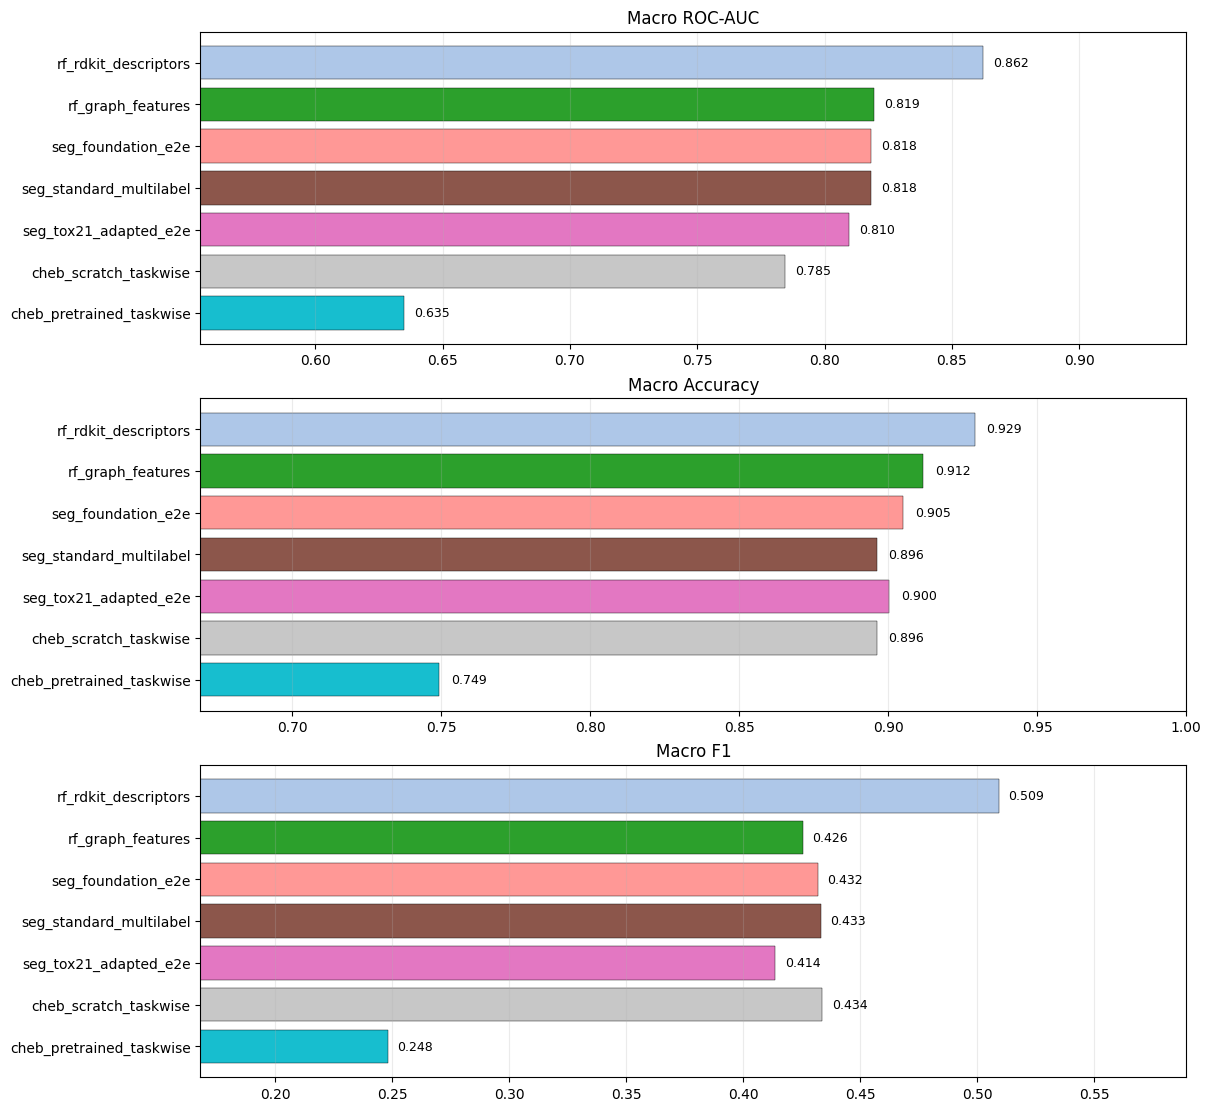

Saved comparison CSV to: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\tox21_baseline_comparison.csv


In [10]:
comparison_df = pd.DataFrame([
    {'model': 'rf_graph_features', 'n_valid_auc_tasks': rf_graph_metrics['n_valid_auc_tasks'], 'best_val_loss': np.nan, **{k:v for k,v in rf_graph_metrics.items() if k.startswith('macro_')}},
    {'model': 'rf_rdkit_descriptors', 'n_valid_auc_tasks': rf_desc_metrics['n_valid_auc_tasks'], 'best_val_loss': np.nan, **{k:v for k,v in rf_desc_metrics.items() if k.startswith('macro_')}},
    {'model': 'cheb_scratch_taskwise', 'n_valid_auc_tasks': cheb_scratch_metrics['n_valid_auc_tasks'], 'best_val_loss': cheb_scratch_best_val, **{k:v for k,v in cheb_scratch_metrics.items() if k.startswith('macro_')}},
    {'model': 'cheb_pretrained_taskwise', 'n_valid_auc_tasks': cheb_pretrained_metrics['n_valid_auc_tasks'], 'best_val_loss': cheb_pretrained_best_val, **{k:v for k,v in cheb_pretrained_metrics.items() if k.startswith('macro_')}},
    {'model': 'seg_standard_multilabel', 'n_valid_auc_tasks': seg_metrics['n_valid_auc_tasks'], 'best_val_loss': seg_best_val, **{k:v for k,v in seg_metrics.items() if k.startswith('macro_')}},
    {'model': 'seg_foundation_e2e', 'n_valid_auc_tasks': seg_foundation_e2e_metrics['n_valid_auc_tasks'], 'best_val_loss': seg_foundation_e2e_best_val, **{k:v for k,v in seg_foundation_e2e_metrics.items() if k.startswith('macro_')}},
    {'model': 'seg_tox21_adapted_e2e', 'n_valid_auc_tasks': seg_tox21_adapted_e2e_metrics['n_valid_auc_tasks'], 'best_val_loss': seg_tox21_adapted_e2e_best_val, **{k:v for k,v in seg_tox21_adapted_e2e_metrics.items() if k.startswith('macro_')}},
])

comparison_df = comparison_df.sort_values('macro_roc_auc', ascending=False).reset_index(drop=True)
display(comparison_df)

metrics_to_plot = ['macro_roc_auc', 'macro_accuracy', 'macro_f1']
titles = ['Macro ROC-AUC', 'Macro Accuracy', 'Macro F1']
palette = plt.cm.tab20(np.linspace(0.08, 0.92, len(comparison_df)))

fig, axes = plt.subplots(3, 1, figsize=(12, 11), constrained_layout=True)
for ax, metric_name, title in zip(axes, metrics_to_plot, titles):
    values = comparison_df[metric_name].values
    y = np.arange(len(comparison_df))
    bars = ax.barh(y, values, color=palette, edgecolor='black', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(comparison_df['model'])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

    xmin = max(0.0, float(np.nanmin(values) - 0.08))
    xmax = min(1.0, float(np.nanmax(values) + 0.08))
    ax.set_xlim(xmin, xmax)

    for bar, v in zip(bars, values):
        ax.text(v + 0.004, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center', fontsize=9)

plt.show()

out_csv = workspace_root / 'benchmarking' / 'results' / 'tox21_baseline_comparison.csv'
comparison_df.to_csv(out_csv, index=False)
print(f'Saved comparison CSV to: {out_csv}')

## Multi-Seed Vergleich (optional, sehr teuer)

Hinweis: Task-wise Cheb (12 Modelle pro Variante) macht Multi-Seed auf Tox21 sehr teuer.
Setze `MULTI_RUN = True`, wenn du alle 7 Baselines auch ueber mehrere Seeds laufen lassen willst.

In [11]:
import time

MULTI_RUN = False
MULTI_SEEDS = [42, 113, 271]
print('Multi-seed setup:', MULTI_SEEDS, '| enabled:', MULTI_RUN)

def run_all_baselines_for_seed(seed_i, verbose=False):
    set_all_seeds(seed_i)
    t0 = time.time()

    rf_graph_metrics_i, _, _, _ = fit_rf_taskwise(
        g_train, train_y, train_w,
        g_valid, valid_y, valid_w,
        g_test, test_y, test_w,
        seed=seed_i,
    )

    rf_desc_metrics_i, _, _, _ = fit_rf_taskwise(
        d_train, train_y, train_w,
        d_valid, valid_y, valid_w,
        d_test, test_y, test_w,
        seed=seed_i,
    )

    cheb_scratch_metrics_i, _, _, _, cheb_scratch_best_val_i = fit_cheb_taskwise(
        train_smiles, train_y, train_w,
        valid_smiles, valid_y, valid_w,
        test_smiles, test_y, test_w,
        seed=seed_i,
        pretrained_ckpt=None,
        use_two_stage=False,
        verbose=verbose,
    )

    cheb_pretrained_metrics_i, _, _, _, cheb_pretrained_best_val_i = fit_cheb_taskwise(
        train_smiles, train_y, train_w,
        valid_smiles, valid_y, valid_w,
        test_smiles, test_y, test_w,
        seed=seed_i,
        pretrained_ckpt=pretrained_ckpt,
        use_two_stage=True,
        verbose=verbose,
    )

    seg_i = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
    seg_hist_i = seg_i.fit(
        smiles_list=train_smiles, labels=train_y_nan,
        val_smiles=valid_smiles, val_labels=valid_y_nan,
        text_embeddings=train_emb, val_text_embeddings=valid_emb,
        num_epochs=SEG_FIT_KWARGS['num_epochs'],
        batch_size=SEG_FIT_KWARGS['batch_size'],
        learning_rate=SEG_FIT_KWARGS['learning_rate'],
        weight_decay=SEG_FIT_KWARGS['weight_decay'],
        patience=SEG_FIT_KWARGS['patience'],
        scheduler=SEG_FIT_KWARGS['scheduler'],
        scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
        scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
        min_lr=SEG_FIT_KWARGS['min_lr'],
        grad_clip=SEG_FIT_KWARGS['grad_clip'],
        seed=int(seed_i),
        verbose=verbose,
    )
    seg_best_val_i = float(np.nanmin(seg_hist_i['val_loss']))
    seg_valid_pred_i = seg_i.predict_batch(valid_smiles, text_embeddings=valid_emb)
    seg_test_pred_i = seg_i.predict_batch(test_smiles, text_embeddings=test_emb)
    seg_thr_i = np.array([best_threshold_binary(valid_y[valid_w[:, t], t], seg_valid_pred_i[valid_w[:, t], t]) if np.sum(valid_w[:, t]) > 0 else 0.5 for t in range(n_tasks)], dtype=np.float32)
    seg_metrics_i = multilabel_metrics(test_y, seg_test_pred_i, test_w, thresholds=seg_thr_i)

    cheb_foundation_backbone_i = make_cheb_backbone_from_pretraining(pretrained_ckpt, train_smiles)
    seg_foundation_e2e_i = SEGPredictor(
        config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
        device=str(device),
    )
    seg_foundation_e2e_i.init_from_cheb(cheb_foundation_backbone_i)
    seg_foundation_e2e_hist_i, seg_foundation_e2e_best_val_i = fit_seg_two_stage(
        seg_foundation_e2e_i,
        train_smiles, train_y_nan,
        valid_smiles, valid_y_nan,
        train_text_embeddings=train_emb,
        valid_text_embeddings=valid_emb,
        seed=int(seed_i),
        batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
        frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
        unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
        fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
        encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
        weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
        patience=SEG_TRANSFER_FIT_KWARGS['patience'],
        verbose=verbose,
    )
    seg_foundation_valid_pred_i = seg_foundation_e2e_i.predict_batch(valid_smiles, text_embeddings=valid_emb)
    seg_foundation_test_pred_i = seg_foundation_e2e_i.predict_batch(test_smiles, text_embeddings=test_emb)
    seg_foundation_thr_i = np.array([best_threshold_binary(valid_y[valid_w[:, t], t], seg_foundation_valid_pred_i[valid_w[:, t], t]) if np.sum(valid_w[:, t]) > 0 else 0.5 for t in range(n_tasks)], dtype=np.float32)
    seg_foundation_e2e_metrics_i = multilabel_metrics(test_y, seg_foundation_test_pred_i, test_w, thresholds=seg_foundation_thr_i)

    mix_train_smiles_i, mix_train_labels_i = build_mixed_task_binary_dataset(train_smiles, train_y, train_w)
    mix_valid_smiles_i, mix_valid_labels_i = build_mixed_task_binary_dataset(valid_smiles, valid_y, valid_w)
    cheb_tox21_adapted_i = ChebPredictor(config=make_tox21_cheb_config(), device=str(device))
    _, _ = fit_two_stage(
        cheb_tox21_adapted_i,
        mix_train_smiles_i, mix_train_labels_i,
        mix_valid_smiles_i, mix_valid_labels_i,
        seed=int(seed_i),
        batch_size=CHEB_FIT_KWARGS['batch_size'],
        frozen_epochs=CHEB_FIT_KWARGS['frozen_epochs'],
        unfreeze_epochs=CHEB_FIT_KWARGS['unfreeze_epochs'],
        head_lr=CHEB_FIT_KWARGS['head_lr'],
        encoder_lr=CHEB_FIT_KWARGS['encoder_lr'],
        weight_decay=CHEB_FIT_KWARGS['weight_decay'],
        patience=CHEB_FIT_KWARGS['patience'],
        pretrained_ckpt=pretrained_ckpt,
        verbose=verbose,
    )

    seg_tox21_adapted_e2e_i = SEGPredictor(
        config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
        device=str(device),
    )
    seg_tox21_adapted_e2e_i.init_from_cheb(cheb_tox21_adapted_i)
    seg_tox21_adapted_e2e_hist_i, seg_tox21_adapted_e2e_best_val_i = fit_seg_two_stage(
        seg_tox21_adapted_e2e_i,
        train_smiles, train_y_nan,
        valid_smiles, valid_y_nan,
        train_text_embeddings=train_emb,
        valid_text_embeddings=valid_emb,
        seed=int(seed_i),
        batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
        frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
        unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
        fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
        encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
        weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
        patience=SEG_TRANSFER_FIT_KWARGS['patience'],
        verbose=verbose,
    )
    seg_tox21_adapted_valid_pred_i = seg_tox21_adapted_e2e_i.predict_batch(valid_smiles, text_embeddings=valid_emb)
    seg_tox21_adapted_test_pred_i = seg_tox21_adapted_e2e_i.predict_batch(test_smiles, text_embeddings=test_emb)
    seg_tox21_adapted_thr_i = np.array([best_threshold_binary(valid_y[valid_w[:, t], t], seg_tox21_adapted_valid_pred_i[valid_w[:, t], t]) if np.sum(valid_w[:, t]) > 0 else 0.5 for t in range(n_tasks)], dtype=np.float32)
    seg_tox21_adapted_e2e_metrics_i = multilabel_metrics(test_y, seg_tox21_adapted_test_pred_i, test_w, thresholds=seg_tox21_adapted_thr_i)

    rows = [
        {'seed': int(seed_i), 'model': 'rf_graph_features', 'best_val_loss': np.nan, **{k:v for k,v in rf_graph_metrics_i.items() if k.startswith('macro_') or k=='n_valid_auc_tasks'}},
        {'seed': int(seed_i), 'model': 'rf_rdkit_descriptors', 'best_val_loss': np.nan, **{k:v for k,v in rf_desc_metrics_i.items() if k.startswith('macro_') or k=='n_valid_auc_tasks'}},
        {'seed': int(seed_i), 'model': 'cheb_scratch_taskwise', 'best_val_loss': cheb_scratch_best_val_i, **{k:v for k,v in cheb_scratch_metrics_i.items() if k.startswith('macro_') or k=='n_valid_auc_tasks'}},
        {'seed': int(seed_i), 'model': 'cheb_pretrained_taskwise', 'best_val_loss': cheb_pretrained_best_val_i, **{k:v for k,v in cheb_pretrained_metrics_i.items() if k.startswith('macro_') or k=='n_valid_auc_tasks'}},
        {'seed': int(seed_i), 'model': 'seg_standard_multilabel', 'best_val_loss': seg_best_val_i, **{k:v for k,v in seg_metrics_i.items() if k.startswith('macro_') or k=='n_valid_auc_tasks'}},
        {'seed': int(seed_i), 'model': 'seg_foundation_e2e', 'best_val_loss': seg_foundation_e2e_best_val_i, **{k:v for k,v in seg_foundation_e2e_metrics_i.items() if k.startswith('macro_') or k=='n_valid_auc_tasks'}},
        {'seed': int(seed_i), 'model': 'seg_tox21_adapted_e2e', 'best_val_loss': seg_tox21_adapted_e2e_best_val_i, **{k:v for k,v in seg_tox21_adapted_e2e_metrics_i.items() if k.startswith('macro_') or k=='n_valid_auc_tasks'}},
    ]

    if verbose:
        elapsed = time.time() - t0
        print(f'Seed {seed_i} done in {elapsed/60.0:.2f} min')

    return rows

if MULTI_RUN:
    all_rows = []
    for i, s in enumerate(MULTI_SEEDS, start=1):
        print(f'[{i}/{len(MULTI_SEEDS)}] Running seed {s} ...')
        seed_rows = run_all_baselines_for_seed(s, verbose=False)
        all_rows.extend(seed_rows)
        seed_df = pd.DataFrame(seed_rows).sort_values('macro_roc_auc', ascending=False).reset_index(drop=True)
        print(seed_df[['model', 'macro_roc_auc', 'macro_accuracy', 'macro_f1']].head(3))

    multi_seed_raw_df = pd.DataFrame(all_rows)
    display(multi_seed_raw_df.head())
    print(f'Collected rows: {len(multi_seed_raw_df)}')

    def summarize_multi_seed(df):
        g = df.groupby('model', as_index=False)
        summary = g.agg(
            n_runs=('seed', 'count'),
            best_val_loss_mean=('best_val_loss', 'mean'),
            best_val_loss_std=('best_val_loss', 'std'),
            macro_roc_auc_mean=('macro_roc_auc', 'mean'),
            macro_roc_auc_std=('macro_roc_auc', 'std'),
            macro_accuracy_mean=('macro_accuracy', 'mean'),
            macro_accuracy_std=('macro_accuracy', 'std'),
            macro_f1_mean=('macro_f1', 'mean'),
            macro_f1_std=('macro_f1', 'std'),
            n_valid_auc_tasks_mean=('n_valid_auc_tasks', 'mean'),
        )

        for metric in ['macro_roc_auc', 'macro_accuracy', 'macro_f1']:
            sem = summary[f'{metric}_std'] / np.sqrt(summary['n_runs'].clip(lower=1))
            summary[f'{metric}_sem'] = sem
            summary[f'{metric}_ci95'] = 1.96 * sem

        return summary.sort_values('macro_roc_auc_mean', ascending=False).reset_index(drop=True)

    multi_seed_summary_df = summarize_multi_seed(multi_seed_raw_df)
    display(multi_seed_summary_df)

    metrics = [
        ('macro_roc_auc', 'Macro ROC-AUC'),
        ('macro_accuracy', 'Macro Accuracy'),
        ('macro_f1', 'Macro F1'),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(13, 11), constrained_layout=True)
    palette = plt.cm.Set2(np.linspace(0.08, 0.92, len(multi_seed_summary_df)))

    for ax, (m, title) in zip(axes, metrics):
        means = multi_seed_summary_df[f'{m}_mean'].values
        ci95 = multi_seed_summary_df[f'{m}_ci95'].fillna(0.0).values
        y = np.arange(len(multi_seed_summary_df))

        ax.barh(
            y, means,
            xerr=ci95,
            color=palette,
            edgecolor='black',
            linewidth=0.3,
            error_kw={'elinewidth': 1.1, 'capsize': 3, 'alpha': 0.9},
        )
        ax.set_yticks(y)
        ax.set_yticklabels(multi_seed_summary_df['model'])
        ax.invert_yaxis()
        ax.set_title(f"{title} (mean +/- 95% CI, n={int(multi_seed_summary_df['n_runs'].iloc[0])})")
        ax.grid(axis='x', alpha=0.25)

        for yi, mu, ci in zip(y, means, ci95):
            ax.text(mu + ci + 0.004, yi, f'{mu:.3f} +/- {ci:.3f}', va='center', fontsize=9)

    plt.show()

    raw_out = workspace_root / 'benchmarking' / 'results' / 'tox21_baseline_comparison_multiseed_raw.csv'
    sum_out = workspace_root / 'benchmarking' / 'results' / 'tox21_baseline_comparison_multiseed_summary.csv'
    multi_seed_raw_df.to_csv(raw_out, index=False)
    multi_seed_summary_df.to_csv(sum_out, index=False)
    print(f'Saved multi-seed raw CSV: {raw_out}')
    print(f'Saved multi-seed summary CSV: {sum_out}')
else:
    print('Multi-seed disabled. Set MULTI_RUN=True to execute.')

Multi-seed setup: [42, 113, 271] | enabled: False
Multi-seed disabled. Set MULTI_RUN=True to execute.
